In [1]:
# =============================================================================
# PatchCore + ResNet-50 Baseline | Few-Shot Industrial Anomaly Detection
# Check Point 2
# MVTec AD — Bottle Category
# Author: Phumapiwat Chanyuthagorn | RIT MS AI
#
# HOW TO USE IN GOOGLE COLAB:
#   1. Runtime -> Change runtime type -> T4 GPU
#   2. Run Cell 1 (install). Runtime will restart — that is normal.
#   3. Upload bottle.zip via the Colab file panel (left sidebar -> upload)
#      OR use: from google.colab import files; files.upload()
#   4. Run Cell 2 (setup folders + unzip)
#   5. Run the remaining cells in order
#
# ADDING MORE CATEGORIES LATER:
#   - Upload the new category zip (such as cable.zip)
#   - Add it to the unzip command in Cell 2
#   - Change CATEGORY in Cell 3 to the new category name
# =============================================================================

In [2]:
# ── CELL 1 : Install dependencies ───────────────────────────────────────────
# Run this once. The runtime will restart automatically — that is normal.
# After restart, skip this cell and start from Cell 2.

!pip install anomalib==1.1.0 -q
!pip install timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.4/424.4 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.5/786.5 kB 54.0 MB/s eta 0:00:00


In [3]:
# ── CELL 2 : Setup dataset folder and unzip ─────────────────────────────────
# Make sure bottle.zip is already uploaded to /content/ before running the this.
# To upload: use the file panel on the left sidebar in Colab, or run:
#   from google.colab import files; files.upload()
# then move it: !mv bottle.zip /content/datasets
#
# If you add more categories later, just add more unzip lines below.

!mkdir -p /content/datasets/

In [4]:
!unzip -q /content/bottle -d /content/datasets/

In [5]:
# Verify structure
import os
bottle_path = "/content/datasets/bottle"
print("Dataset structure:")
for split in ['train', 'test']:
    split_path = os.path.join(bottle_path, split)
    if os.path.exists(split_path):
        subtypes = os.listdir(split_path)
        for s in sorted(subtypes):
            n = len(os.listdir(os.path.join(split_path, s)))
            print(f"  {split}/{s}: {n} images")

Dataset structure:
  train/good: 209 images
  test/broken_large: 20 images
  test/broken_small: 22 images
  test/contamination: 21 images
  test/good: 20 images


In [6]:
# ── CELL 3 : Imports and configuration ──────────────────────────────────────
import random
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gc

from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import roc_auc_score
from PIL import Image

# ── Dataset path ──
DATASET_ROOT = Path("/content/datasets")

# ── Experiment settings ──
CATEGORY        = "bottle"   # Change this when adding more categories
SHOT_COUNTS     = [1, 5, 10, -1]   # -1 means "use all training images"
IMAGE_SIZE      = 224
SUBSAMPLE_RATIO = 0.01      # 1% coreset keeps memory small; raise to 0.1 for better accuracy
BATCH_SIZE      = 32
SEED            = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4


In [7]:
# ── CELL 4 : Dataset class ───────────────────────────────────────────────────

class MVTecFewShotDataset(Dataset):
    """
    MVTec AD loader with few-shot support.

    Args:
        root       : Path to the category folder (such as /content/datasets/bottle)
        split      : 'train' or 'test'
        n_shot     : Number of normal training images to use. None = use all.
        image_size : Resize to this square size
        seed       : Random seed for reproducible sampling
    """

    def __init__(self, root, split="train", n_shot=None, image_size=224, seed=42):
        self.root = Path(root)
        self.split = split
        self.image_size = image_size

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

        self.samples = []   # list of (image_path, label, mask_path_or_None)
        self._load_samples(n_shot, seed)

    def _load_samples(self, n_shot, seed):
        if self.split == "train":
            normal_dir = self.root / "train" / "good"
            paths = sorted(normal_dir.glob("*.png")) + sorted(normal_dir.glob("*.jpg"))
            if n_shot is not None:
                rng = random.Random(seed)
                paths = rng.sample(paths, min(n_shot, len(paths)))
            self.samples = [(p, 0, None) for p in paths]

        elif self.split == "test":
            test_dir = self.root / "test"
            mask_dir = self.root / "ground_truth"
            for defect_type in sorted(test_dir.iterdir()):
                label = 0 if defect_type.name == "good" else 1
                img_paths = sorted(defect_type.glob("*.png")) + sorted(defect_type.glob("*.jpg"))
                for img_path in img_paths:
                    if label == 0:
                        self.samples.append((img_path, label, None))
                    else:
                        mask_path = mask_dir / defect_type.name / (img_path.stem + "_mask.png")
                        self.samples.append((img_path, label,
                                             mask_path if mask_path.exists() else None))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, mask_path = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        mask = torch.zeros(1, self.image_size, self.image_size)
        if mask_path is not None and mask_path.exists():
            m = Image.open(mask_path).convert("L")
            m = transforms.Resize(
                (self.image_size, self.image_size),
                interpolation=transforms.InterpolationMode.NEAREST
            )(m)
            mask = (transforms.ToTensor()(m) > 0.5).float()

        return {"image": image, "label": label, "mask": mask, "path": str(img_path)}


def make_loaders(category, n_shot, dataset_root=DATASET_ROOT,
                 image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, seed=SEED):
    root = dataset_root / category
    train_ds = MVTecFewShotDataset(root, "train", n_shot=n_shot,
                                    image_size=image_size, seed=seed)
    test_ds  = MVTecFewShotDataset(root, "test",  n_shot=None,
                                    image_size=image_size, seed=seed)
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                               shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                               shuffle=False, num_workers=2, pin_memory=True)
    label = "Full" if n_shot is None else f"{n_shot}-shot"
    print(f"  [{category}] {label} | train={len(train_ds)} | test={len(test_ds)}")
    return train_loader, test_loader


# Quick sanity check
print("\nDataset check:")
_ = make_loaders(CATEGORY, n_shot=5)


Dataset check:
  [bottle] 5-shot | train=5 | test=83


In [8]:
# ── CELL 5 : PatchCore model ─────────────────────────────────────────────────

class ResNet50Extractor(nn.Module):
    """
    Extracts multi-scale features from ResNet-50 layer2 and layer3.
    Both layers are used because:
      layer2 (512ch, stride 8)  -> fine texture detail
      layer3 (1024ch, stride 16) -> structural / semantic context
    Concatenated = 1536-dim patch descriptors.
    """
    def __init__(self, device):
        super().__init__()
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        backbone.eval()
        self.layer0 = nn.Sequential(backbone.conv1, backbone.bn1,
                                     backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.to(device)
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x):
        x  = self.layer0(x)
        x  = self.layer1(x)
        f2 = self.layer2(x)   # [B, 512,  H/8,  W/8]
        f3 = self.layer3(f2)  # [B, 1024, H/16, W/16]
        return f2, f3


def neighbourhood_pool(features, kernel_size=3):
    """Average pool to aggregate local neighbourhood context per patch."""
    return F.avg_pool2d(features, kernel_size=kernel_size,
                        stride=1, padding=kernel_size // 2)


def extract_features(loader, extractor, device):
    """Extract all patch features from a dataloader. Returns [N_patches, 1536]."""
    all_feats = []
    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            f2, f3 = extractor(images)
            f2 = neighbourhood_pool(f2)
            f3 = neighbourhood_pool(f3)
            _, _, H2, W2 = f2.shape
            f3_up = F.interpolate(f3, size=(H2, W2), mode="bilinear", align_corners=False)
            combined = torch.cat([f2, f3_up], dim=1)   # [B, 1536, H2, W2]
            B, C, H, W = combined.shape
            patches = combined.permute(0, 2, 3, 1).reshape(-1, C)
            all_feats.append(patches.cpu())
    return torch.cat(all_feats, dim=0)


def coreset_subsample(features, ratio=0.01, seed=42):
    """Random coreset subsampling (fast approximation of greedy coreset)."""
    N = features.shape[0]
    n_keep = max(1, int(N * ratio))
    if n_keep >= N:
        return features
    rng = np.random.default_rng(seed)
    idx = rng.choice(N, size=n_keep, replace=False)
    print(f"    Coreset: {N} -> {n_keep} patches ({ratio*100:.1f}%)")
    return features[idx]


class PatchCoreResNet50:
    """
    Full PatchCore pipeline with ResNet-50 backbone.

    fit(train_loader)     -> builds memory bank from normal images
    evaluate(test_loader) -> returns AUROC + all raw scores for analysis
    """
    def __init__(self, device="cuda", image_size=224, subsample_ratio=0.01):
        self.device = device
        self.image_size = image_size
        self.subsample_ratio = subsample_ratio
        self.extractor = ResNet50Extractor(device)
        self.memory_bank = None

    def fit(self, train_loader):
        print("  Extracting training features...")
        t0 = time.time()
        features = extract_features(train_loader, self.extractor, self.device)
        features = coreset_subsample(features, self.subsample_ratio)
        self.memory_bank = features.to(self.device)
        print(f"  Memory bank: {self.memory_bank.shape} | {time.time()-t0:.1f}s")

    def _score_batch(self, images):
        """Returns per-image max anomaly score and upsampled score map."""
        f2, f3 = self.extractor(images)
        f2 = neighbourhood_pool(f2)
        f3 = neighbourhood_pool(f3)
        _, _, H2, W2 = f2.shape
        f3_up = F.interpolate(f3, size=(H2, W2), mode="bilinear", align_corners=False)
        combined = torch.cat([f2, f3_up], dim=1)
        B, C, H, W = combined.shape
        patches = combined.permute(0, 2, 3, 1).reshape(-1, C)

        # KNN distance in chunks to avoid OOM
        nn_dists = []
        for chunk in patches.split(1024):
            d = torch.cdist(chunk, self.memory_bank)
            nn_dists.append(d.min(dim=1).values)
        nn_dists = torch.cat(nn_dists).reshape(B, H, W)

        score_map = F.interpolate(
            nn_dists.unsqueeze(1).float(),
            size=(self.image_size, self.image_size),
            mode="bilinear", align_corners=False
        ).squeeze(1)   # [B, 224, 224]

        image_scores = score_map.reshape(B, -1).max(dim=1).values
        return image_scores, score_map

    def evaluate(self, test_loader):
        print("  Scoring test images...")
        t0 = time.time()
        all_scores, all_labels, all_masks, all_maps = [], [], [], []
        with torch.no_grad():
            for batch in test_loader:
                images = batch["image"].to(self.device)
                scores, maps = self._score_batch(images)
                all_scores.append(scores.cpu())
                all_labels.append(batch["label"])
                all_masks.append(batch["mask"])
                all_maps.append(maps.cpu())

        scores = torch.cat(all_scores).numpy()
        labels = torch.cat(all_labels).numpy()
        masks  = torch.cat(all_masks).numpy()
        maps   = torch.cat(all_maps).numpy()

        auroc = roc_auc_score(labels, scores)
        print(f"  Image AUROC: {auroc:.4f} | {time.time()-t0:.1f}s")
        return auroc, scores, labels, masks, maps

In [9]:
# ── CELL 6 : Run experiment ──────────────────────────────────────────────────

results = {}        # results[shot_label] = auroc
all_eval_data = {}  # store for visualization

print(f"\n{'='*55}")
print(f"  PatchCore + ResNet-50  |  Category: {CATEGORY.upper()}")
print(f"{'='*55}")

for n_shot in SHOT_COUNTS:
    shot_label = "Full" if n_shot == -1 else f"{n_shot}-shot"
    n = None if n_shot == -1 else n_shot
    print(f"\n>> {shot_label}")

    train_loader, test_loader = make_loaders(CATEGORY, n_shot=n)
    model = PatchCoreResNet50(device=device, image_size=IMAGE_SIZE,
                               subsample_ratio=SUBSAMPLE_RATIO)
    model.fit(train_loader)
    auroc, scores, labels, masks, maps = model.evaluate(test_loader)

    results[shot_label] = auroc
    all_eval_data[shot_label] = {
        "scores": scores, "labels": labels,
        "masks": masks, "maps": maps,
        "test_loader": test_loader
    }

    del model
    torch.cuda.empty_cache()
    gc.collect()

print(f"\n{'='*40}")
print(f"  Results — {CATEGORY}")
print(f"{'='*40}")
for label, auroc in results.items():
    print(f"  {label:>8s}  AUROC = {auroc:.4f}")
print(f"{'='*40}")



  PatchCore + ResNet-50  |  Category: BOTTLE

>> 1-shot
  [bottle] 1-shot | train=1 | test=83
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 192MB/s]


  Extracting training features...
    Coreset: 784 -> 7 patches (1.0%)
  Memory bank: torch.Size([7, 1536]) | 1.0s
  Scoring test images...
  Image AUROC: 0.4611 | 2.6s

>> 5-shot
  [bottle] 5-shot | train=5 | test=83
  Extracting training features...
    Coreset: 3920 -> 39 patches (1.0%)
  Memory bank: torch.Size([39, 1536]) | 0.5s
  Scoring test images...
  Image AUROC: 0.7460 | 2.6s

>> 10-shot
  [bottle] 10-shot | train=10 | test=83
  Extracting training features...
    Coreset: 7840 -> 78 patches (1.0%)
  Memory bank: torch.Size([78, 1536]) | 0.5s
  Scoring test images...
  Image AUROC: 0.9032 | 2.4s

>> Full
  [bottle] Full | train=209 | test=83
  Extracting training features...
    Coreset: 163856 -> 1638 patches (1.0%)
  Memory bank: torch.Size([1638, 1536]) | 7.9s
  Scoring test images...
  Image AUROC: 1.0000 | 2.4s

  Results — bottle
    1-shot  AUROC = 0.4611
    5-shot  AUROC = 0.7460
   10-shot  AUROC = 0.9032
      Full  AUROC = 1.0000


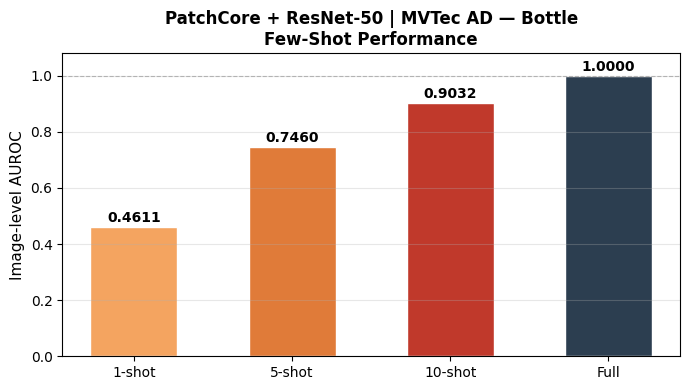

Saved: /content/patchcore_auroc_bar.png


In [10]:
# ── CELL 7 : Results bar chart ───────────────────────────────────────────────

labels_plot = list(results.keys())
auroc_vals  = [results[k] for k in labels_plot]
colors = ["#f4a460", "#e07b39", "#c0392b", "#2c3e50"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels_plot, auroc_vals, color=colors[:len(labels_plot)],
              edgecolor="white", width=0.55)

for bar, val in zip(bars, auroc_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylim(0, 1.08)
ax.set_ylabel("Image-level AUROC", fontsize=11)
ax.set_title(f"PatchCore + ResNet-50 | MVTec AD — {CATEGORY.capitalize()}\n"
             f"Few-Shot Performance", fontsize=12, fontweight="bold")
ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/content/patchcore_auroc_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/patchcore_auroc_bar.png")



Visualizing 1-shot:


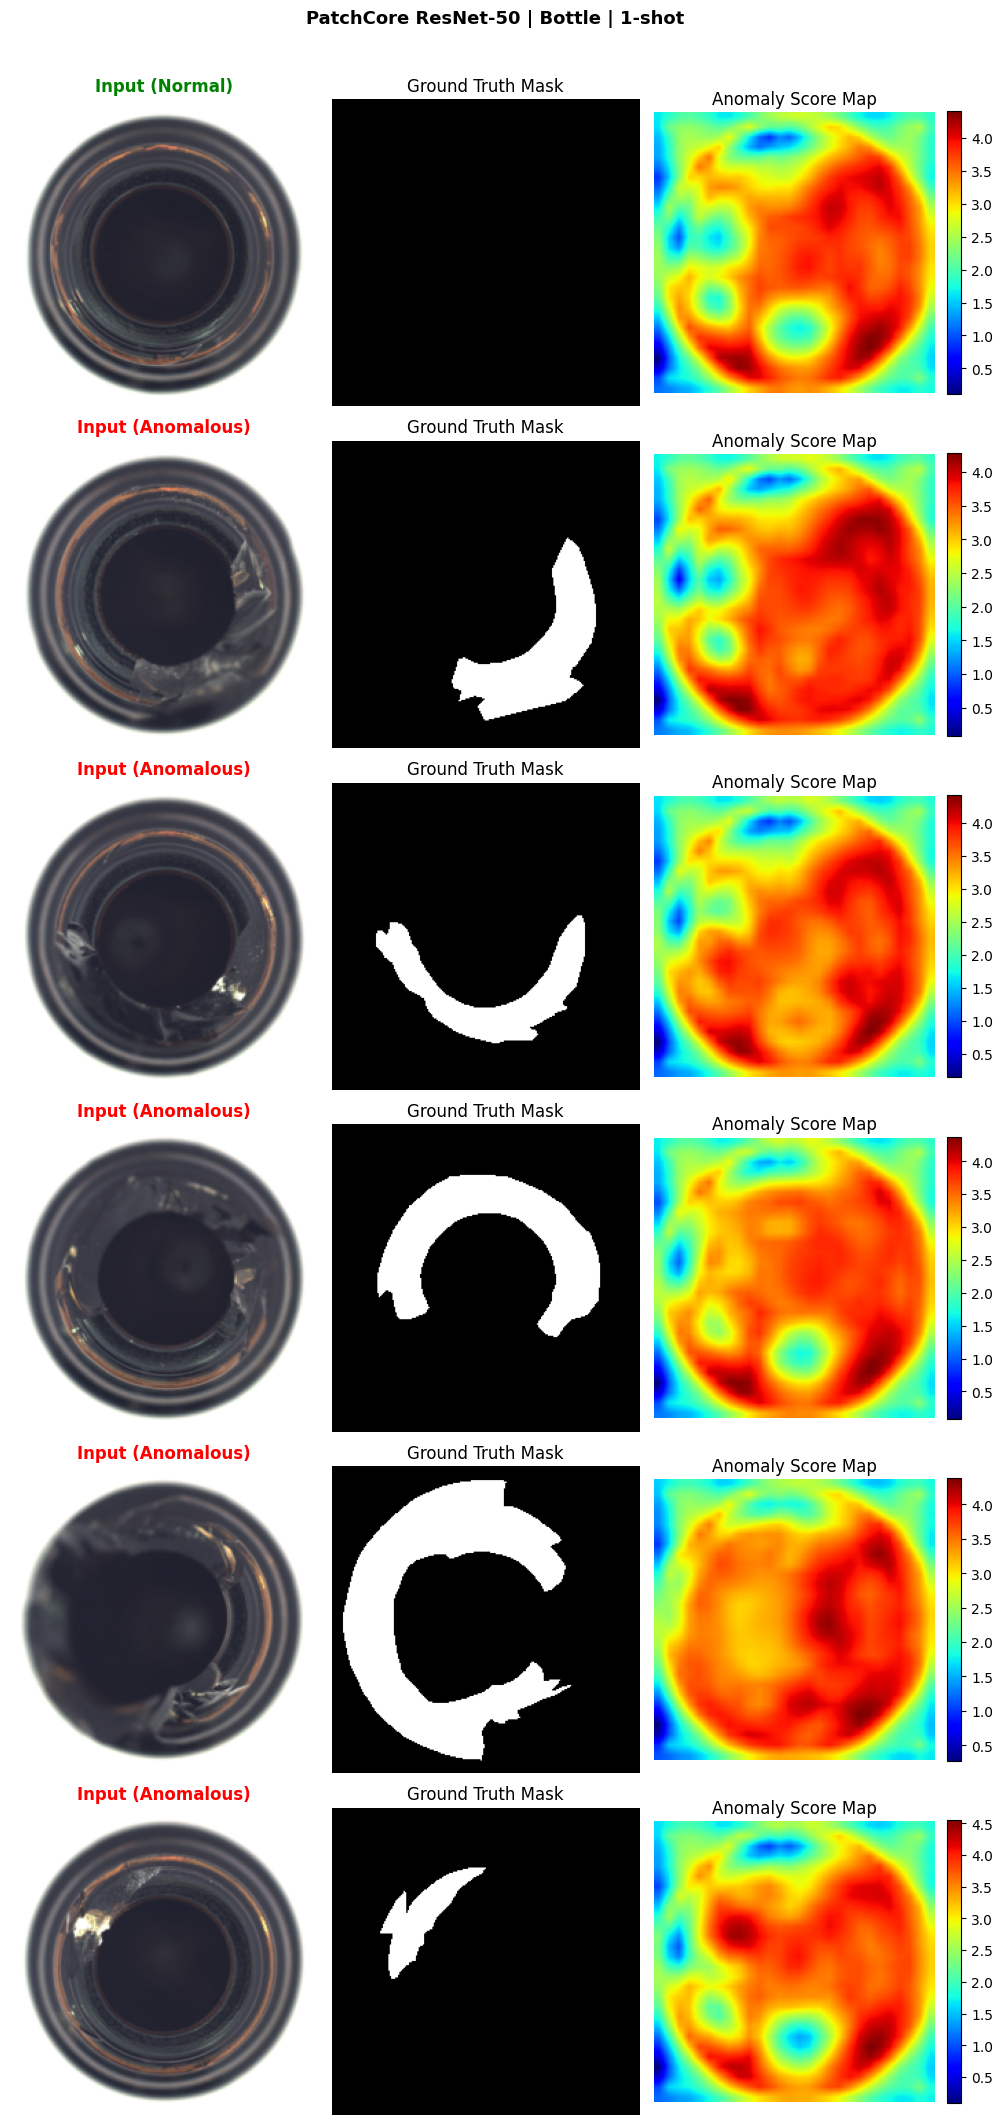

Saved: /content/patchcore_viz_1shot.png

Visualizing Full:


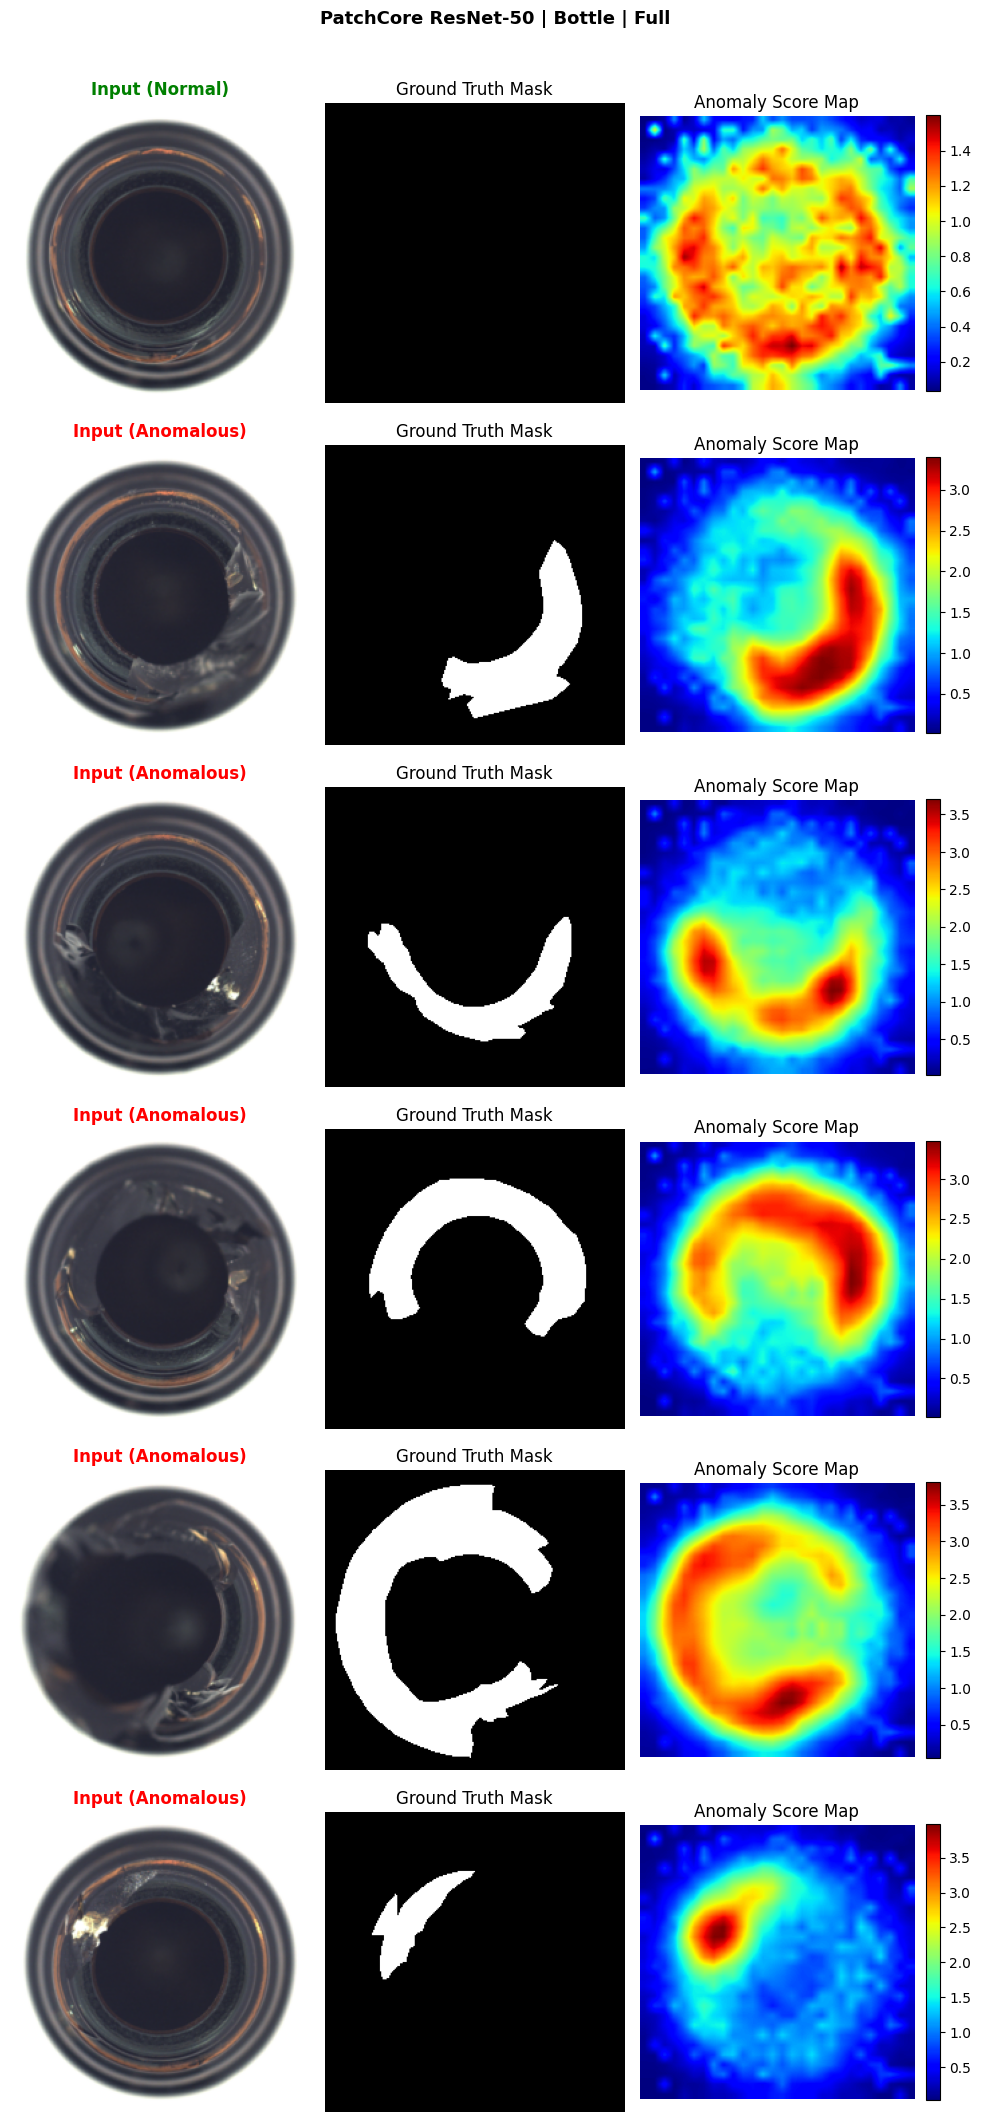

Saved: /content/patchcore_viz_Full.png


In [11]:
# ── CELL 8 : Visualize anomaly score maps ───────────────────────────────────
# Shows: original image | ground truth mask | predicted anomaly heat map
# Green border = normal sample, Red border = anomalous sample

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


def visualize_results(eval_data, shot_label, n_show=6):
    images_list, labels_list, masks_list = [], [], []
    for batch in eval_data["test_loader"]:
        images_list.append(batch["image"])
        labels_list.append(batch["label"])
        masks_list.append(batch["mask"])
        if sum(len(x) for x in images_list) >= 40:
            break

    all_images = torch.cat(images_list)
    all_labels = torch.cat(labels_list)
    all_masks  = torch.cat(masks_list)
    score_maps = eval_data["maps"]

    # Pick a balanced mix of normal and anomalous
    normal_idx = (all_labels == 0).nonzero(as_tuple=True)[0][:n_show // 2].tolist()
    anom_idx   = (all_labels == 1).nonzero(as_tuple=True)[0][:n_show - len(normal_idx)].tolist()
    idx_list   = normal_idx + anom_idx

    fig, axes = plt.subplots(len(idx_list), 3, figsize=(10, 3.5 * len(idx_list)))
    if len(idx_list) == 1:
        axes = axes[np.newaxis, :]

    for row, i in enumerate(idx_list):
        img   = denormalize(all_images[i])
        mask  = all_masks[i, 0].numpy()
        smap  = score_maps[i] if i < len(score_maps) else np.zeros((IMAGE_SIZE, IMAGE_SIZE))
        is_anomalous = all_labels[i].item() == 1
        color = "red" if is_anomalous else "green"
        title = "Anomalous" if is_anomalous else "Normal"

        axes[row, 0].imshow(img)
        axes[row, 0].set_title(f"Input ({title})", color=color, fontweight="bold")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(mask, cmap="gray")
        axes[row, 1].set_title("Ground Truth Mask")
        axes[row, 1].axis("off")

        im = axes[row, 2].imshow(smap, cmap="jet")
        axes[row, 2].set_title("Anomaly Score Map")
        axes[row, 2].axis("off")
        plt.colorbar(im, ax=axes[row, 2], fraction=0.046, pad=0.04)

    fig.suptitle(
        f"PatchCore ResNet-50 | {CATEGORY.capitalize()} | {shot_label}",
        fontsize=13, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    save_path = f"/content/patchcore_viz_{shot_label.replace('-', '')}.png"
    plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved: {save_path}")

# Visualize 1-shot and Full results
for shot_label in ["1-shot", "Full"]:
    print(f"\nVisualizing {shot_label}:")
    visualize_results(all_eval_data[shot_label], shot_label, n_show=6)


In [12]:
# ── CELL 9 : Inference latency benchmark ────────────────────────────────────

def benchmark_latency(n_shot=10, n_trials=50, n_warmup=5):
    train_loader, test_loader = make_loaders(CATEGORY, n_shot=n_shot, batch_size=1)
    model = PatchCoreResNet50(device=device, image_size=IMAGE_SIZE,
                               subsample_ratio=SUBSAMPLE_RATIO)
    model.fit(train_loader)

    test_iter = iter(test_loader)

    # Warmup
    for _ in range(n_warmup):
        try:
            batch = next(test_iter)
        except StopIteration:
            test_iter = iter(test_loader)
            batch = next(test_iter)
        with torch.no_grad():
            model._score_batch(batch["image"].to(device))

    # Timed
    latencies = []
    for _ in range(n_trials):
        try:
            batch = next(test_iter)
        except StopIteration:
            test_iter = iter(test_loader)
            batch = next(test_iter)
        if device == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            model._score_batch(batch["image"].to(device))
        if device == "cuda":
            torch.cuda.synchronize()
        latencies.append((time.perf_counter() - t0) * 1000)

    mean_ms = np.mean(latencies)
    std_ms  = np.std(latencies)
    print(f"\nLatency   : {mean_ms:.2f} ± {std_ms:.2f} ms/image")
    print(f"Throughput: {1000/mean_ms:.1f} images/sec")
    print(f"Memory bank size: {model.memory_bank.shape}")

    del model
    torch.cuda.empty_cache()
    return mean_ms, std_ms

print("Benchmarking inference latency (n_shot=10)...")
benchmark_latency(n_shot=10)

Benchmarking inference latency (n_shot=10)...
  [bottle] 10-shot | train=10 | test=83
  Extracting training features...
    Coreset: 7840 -> 78 patches (1.0%)
  Memory bank: torch.Size([78, 1536]) | 0.7s

Latency   : 16.62 ± 5.34 ms/image
Throughput: 60.2 images/sec
Memory bank size: torch.Size([78, 1536])


(np.float64(16.621842500007915), np.float64(5.337208203257086))

In [13]:
# ── CELL 10 : Save results CSV ───────────────────────────────────────────────

import pandas as pd

df = pd.DataFrame([{
    "category": CATEGORY,
    "model": "PatchCore-ResNet50",
    **results
}])
df.to_csv("/content/baseline_results.csv", index=False)
print("Results saved to /content/baseline_results.csv")
print(df.to_string(index=False))

print("""
==============================================
  DONE — Baseline complete for: bottle

  To add more categories later:
    1. Upload <category>.zip to /content/
    2. Add unzip line in Cell 2:
       !unzip -q /content/<category> -d /content/datasets/
    3. Change CATEGORY = "<category>" in Cell 3
    4. Re-run from Cell 4 onwards
==============================================
""")

Results saved to /content/baseline_results.csv
category              model   1-shot   5-shot  10-shot  Full
  bottle PatchCore-ResNet50 0.461111 0.746032 0.903175   1.0

  DONE — Baseline complete for: bottle
 
  To add more categories later:
    1. Upload <category>.zip to /content/
    2. Add unzip line in Cell 2:
       !unzip -q /content/<category> -d /content/datasets/
    3. Change CATEGORY = "<category>" in Cell 3
    4. Re-run from Cell 4 onwards

